# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

# The Dataset

For this lab, I used a Covid-19 dataset from Kaggle. It has daily case numbers for each country along with their locations, so it’s perfect for showing how Covid-19 changed over time and across different parts of the world.

In [2]:
df = pd.read_csv('covid_19_clean_complete.csv')

In [3]:
df.shape

(49068, 10)

In [4]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


# Visualizations

# 1. Global Confirmed Cases Over Time (Time-Series)

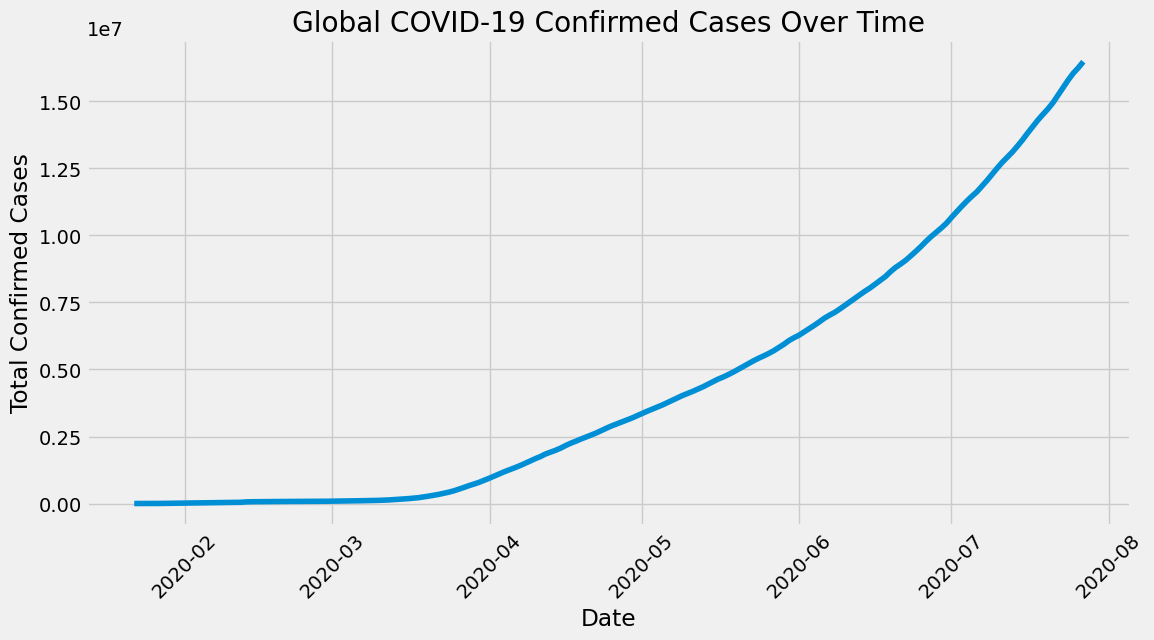

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

global_daily = df.groupby("Date")["Confirmed"].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(global_daily["Date"], global_daily["Confirmed"])
plt.title("Global COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Confirmed Cases")
plt.xticks(rotation=45)
plt.show()

You can see global Covid-19 cases start shooting up fast around March 2020. The line basically shows how quickly the virus spread all over the world in a short amount of time.

# 2. Top 10 Countries by Total Cases (Spatial Comparison)

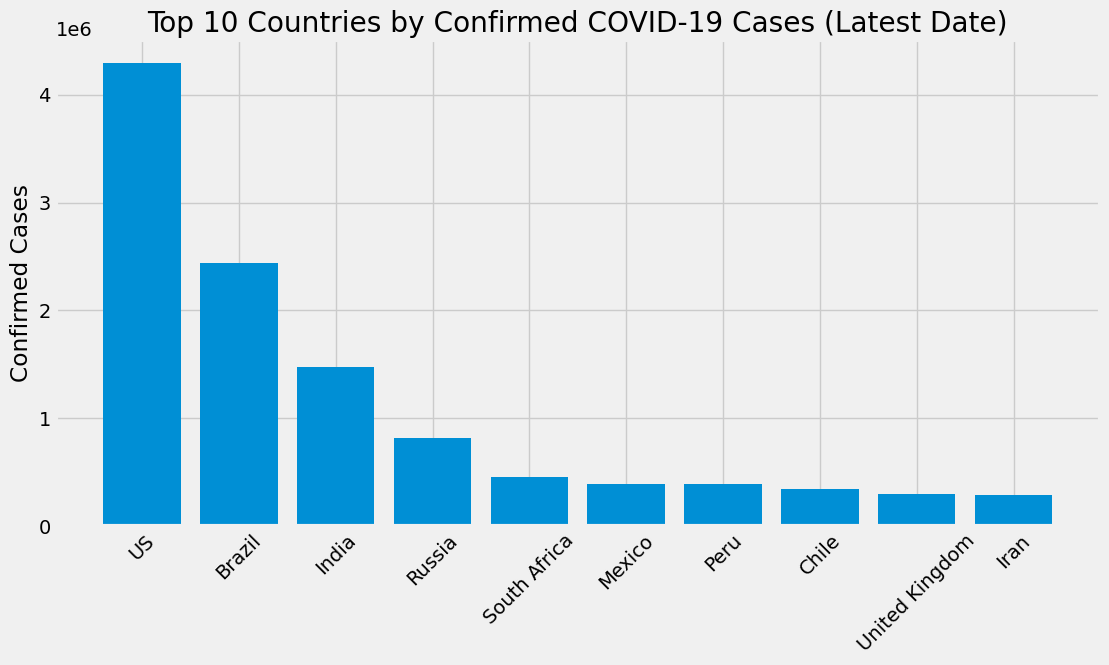

In [6]:
latest = df[df["Date"] == df["Date"].max()]

country_totals = latest.groupby("Country/Region")["Confirmed"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(country_totals.index, country_totals.values)
plt.title("Top 10 Countries by Confirmed COVID-19 Cases (Latest Date)")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()

This bar chart shows the top 10 countries with the most Covid-19 cases. You can see how some countries were hit way harder than others.

# 3. Global Case Spread by Latitude/Longitude (Spatial Map)

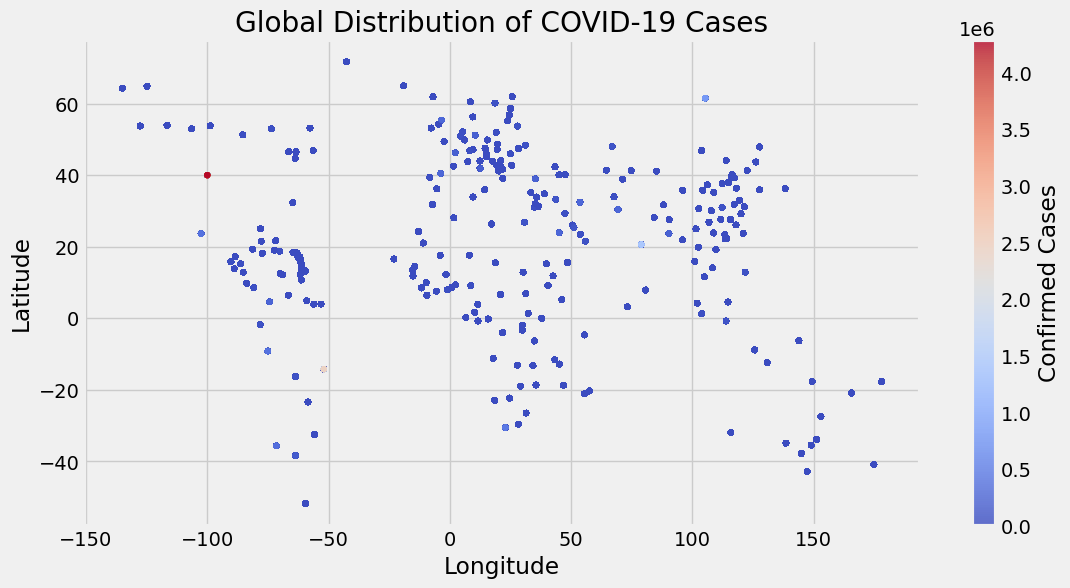

In [10]:
plt.figure(figsize=(12,6))
plt.scatter(df["Long"], df["Lat"], c=df["Confirmed"], cmap="coolwarm", s=20, alpha=0.8, edgecolor="none")
plt.colorbar(label="Confirmed Cases")
plt.title("Global Distribution of COVID-19 Cases")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

This scatter map shows where Covid-19 cases were spread around the world, with darker spots meaning more cases. Most of the big clusters show up in North America, Europe, and parts of Asia.